# NOBELOVE NAGRADE

### UVOZ PODATKOV

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

nagrajenci = pd.read_csv("nobelovi_nagrajenci.csv", index_col="ime")


# podrocje = pd.read_csv("nobelovi_nagrajenci.csv", index_col="področje nagrade")
pd.options.display.max_rows = 20

In [59]:
nagrajenci.head(10)

,datum rojstva,leto rojstva,država rojstva,dan smrti,leto smrti,država smrti,področje nagrade,leto nagrade
ime,,,,,,,,
Jacobus Henricus van't Hoff,30 August,1852,the Netherlands,1 March,1911,Germany,Chemistry,1901
Hermann Emil Fischer,9 October,1852,Germany,15 July,1919,Germany,Chemistry,1902
Svante August Arrhenius,19 February,1859,Sweden,2 October,1927,Sweden,Chemistry,1903
Sir William Ramsay,2 October,1852,Scotland,23 July,1916,United Kingdom,Chemistry,1904
Johann Friedrich Wilhelm Adolf von Baeyer,31 October,1835,Germany,20 August,1917,Germany,Chemistry,1905
Henri Moissan,28 September,1852,France,20 February,1907,France,Chemistry,1906
Eduard Buchner,20 May,1860,Germany,13 August,1917,Romania,Chemistry,1907
Ernest Rutherford,30 August,1871,New Zealand,19 October,1937,United Kingdom,Chemistry,1908
Wilhelm Ostwald,2 September,1853,Latvia,4 April,1932,Germany,Chemistry,1909


### ANALIZA PO PODROČJIH

In [60]:
vsi = nagrajenci["področje nagrade"]
kemija = nagrajenci["področje nagrade"] == "Chemistry"
# kemija.sum()
ekonomija = (
    nagrajenci["področje nagrade"] == "Economic Sciences in Memory of Alfred Nobel"
)
literatura = nagrajenci["področje nagrade"] == "Literature"
medicina_fiziologija = nagrajenci["področje nagrade"] == "Physiology or Medicine"
mir = nagrajenci["področje nagrade"] == "Peace"
fizika = nagrajenci["področje nagrade"] == "Physics"

 Število vseh nobelovih nagrajencev in po posameznih področjih 

In [61]:
print(f"Število vseh dobitnikov: {vsi.count()}")
print(f"Število dobitnikov na področju kemije: {kemija.sum()}")
print(f"Število dobitnikov na področju ekonomije: {ekonomija.sum()}")
print(f"Število dobitnikov na področju literature: {literatura.sum()}")
print(
    f"Število dobitnikov na področju fiziologije ali medecine: {medicina_fiziologija.sum()}"
)
print(f"Število dobitnikov na področju miru: {mir.sum()}")
print(f"Število dobitnikov na področju fizike: {fizika.sum()}")

Število vseh dobitnikov: 1026
Število dobitnikov na področju kemije: 200
Število dobitnikov na področju ekonomije: 99
Število dobitnikov na področju literature: 122
Število dobitnikov na področju fiziologije ali medecine: 232
Število dobitnikov na področju miru: 143
Število dobitnikov na področju fizike: 230


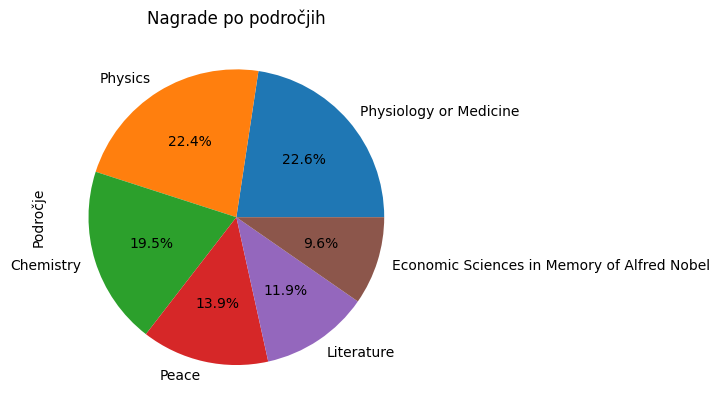

In [62]:
podrocja = nagrajenci["področje nagrade"].value_counts()
# podrocja
graf = podrocja.plot.pie(
    ylabel="Področje", title="Nagrade po področjih", autopct="%1.1f%%"
)

In [63]:
odstrant = nagrajenci[nagrajenci["leto rojstva"] == "/"]
podrocje_ni_oseba = odstrant["področje nagrade"].value_counts()
ni_oseba = len(odstrant)
print(
    f"Število podeljenih nagrad, ki niso bile podeljene posameznikom znaša {ni_oseba} na področju {podrocje_ni_oseba.index[0]}."
)

Število podeljenih nagrad, ki niso bile podeljene posameznikom znaša 31 na področju Peace.


### ANALIZA LET NAGRADE 

In [64]:
leto_podelitve = nagrajenci["leto nagrade"]
najvec_nagraj_leto = leto_podelitve.value_counts()
print(
    f"Leta {najvec_nagraj_leto.index[0]} je bilo podeljenih največ nagrad in sicer {najvec_nagraj_leto.iloc[0]}."
)
# najvec_nagraj_leto

Leta 2001 je bilo podeljenih največ nagrad in sicer 15.


In [65]:
seznam_vseh_let = []
for let in range(1901, 2026):
    seznam_vseh_let.append(let)
for l in leto_podelitve:
    if l in seznam_vseh_let:
        seznam_vseh_let.remove(l)

brez_nagrad = ""
for leto1 in seznam_vseh_let:
    brez_nagrad += " "
    brez_nagrad += f"{str(leto1)},"
print(f"Leta{brez_nagrad} v katerih niso podelili Nobelovih nagrad.")

Leta 1940, 1941, 1942, v katerih niso podelili Nobelovih nagrad.


In [67]:
podrocje_nagra = "Chemistry"  # izberi področje nargarde
leto_podrocji = nagrajenci[nagrajenci["področje nagrade"] == podrocje_nagra]
leto_podrocji1 = leto_podrocji["leto nagrade"]
seznam_vseh_let_podrocja = []
for let in range(1901, 2026):
    seznam_vseh_let_podrocja.append(let)
for l in leto_podrocji1:
    if l in seznam_vseh_let_podrocja:
        seznam_vseh_let_podrocja.remove(l)

brez_nagrad = ""
for leto1 in seznam_vseh_let_podrocja:
    brez_nagrad += " "
    brez_nagrad += f"{str(leto1)},"
print(
    f"Leta{brez_nagrad} v katerih niso podelili Nobelovih nagrad na področju {podrocje_nagra}."
)

Leta 1916, 1917, 1919, 1924, 1933, 1940, 1941, 1942, v katerih niso podelili Nobelovih nagrad na področju Chemistry.


### ANALIZA PO STAROSTI

Povprečna starost ob prejemu nagrad

In [68]:
leto_nagrade = pd.to_numeric(nagrajenci["leto nagrade"], errors="coerce")

leto_rojstva = pd.to_numeric(nagrajenci["leto rojstva"], errors="coerce")
nagrajenci["starost ob nagradi"] = leto_nagrade - leto_rojstva
# print(nagrajenci["starost ob nagradi"])

print(
    f"Povprečna starost ob prejemu nagrade skupaj na vseh področjih znaša {int(nagrajenci["starost ob nagradi"].mean())} let.\n"
    f"Povprečna starost ob prejemu nagrede na področju kemije znaša: {int(nagrajenci['starost ob nagradi'][kemija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrede na področju ekonomije znaša: {int(nagrajenci['starost ob nagradi'][ekonomija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrede na področju literature znaša: {int(nagrajenci['starost ob nagradi'][literatura].mean())} let\n"
    f"Povprečna starost ob prejemu nagrede na področju medicine ali fiziologije znaša: {int(nagrajenci['starost ob nagradi'][medicina_fiziologija].mean())} let\n"
    f"Povprečna starost ob prejemu nagrede na področju miru znaša: {int(nagrajenci['starost ob nagradi'][mir].mean())} let\n"
    f"Povprečna starost ob prejemu nagrede na področju fizike znaša: {int(nagrajenci['starost ob nagradi'][fizika].mean())} let"
)

Povprečna starost ob prejemu nagrade skupaj na vseh področjih znaša 60 let.
Povprečna starost ob prejemu nagrede na področju kemije znaša: 59 let
Povprečna starost ob prejemu nagrede na področju ekonomije znaša: 67 let
Povprečna starost ob prejemu nagrede na področju literature znaša: 64 let
Povprečna starost ob prejemu nagrede na področju medicine ali fiziologije znaša: 58 let
Povprečna starost ob prejemu nagrede na področju miru znaša: 60 let
Povprečna starost ob prejemu nagrede na področju fizike znaša: 57 let


In [80]:
najmlajsi = nagrajenci[
    nagrajenci["starost ob nagradi"] == min(nagrajenci["starost ob nagradi"])
]
najstarejsi = nagrajenci[
    nagrajenci["starost ob nagradi"] == max(nagrajenci["starost ob nagradi"])
]

najmlajsi1 = int(najmlajsi["starost ob nagradi"].iloc[0])
najstarejsi1 = int(najstarejsi["starost ob nagradi"].iloc[0])

print(
    f"Najmlajši prejemnik nagrade je bil/a {najmlajsi.index[0]}, ki je bil/a ob prejemu star/a {najmlajsi1} let.\n"
    f"Najstarejši prejemnik pa je bil/a {najstarejsi.index[0]} ob prejemu star/a {najstarejsi1} let.\n"
    f"Starostna razlika med najstarejšim in najmlajšim prejemnikom nagrade znaša: {najstarejsi1-najmlajsi1} let."
)

Najmlajši prejemnik nagrade je bil/a Malala Yousafzai, ki je bil/a ob prejemu star/a 17 let.
Najstarejši prejemnik pa je bil/a John B. Goodenough ob prejemu star/a 97 let.
Starostna razlika med najstarejšim in najmlajšim prejemnikom nagrade znaša: 80 let.


In [9]:
leto_nagrade = pd.to_numeric(nagrajenci["leto nagrade"], errors="coerce")

leto_smrti = pd.to_numeric(nagrajenci["leto smrti"], errors="coerce")
nagrajenci["število let po nagradi"] = leto_smrti - leto_nagrade

let_po_nagradi = nagrajenci[~nagrajenci["število let po nagradi"].isna()]
povprecje = let_po_nagradi["število let po nagradi"].mean()
print(f"Dobitniki po prejemu nagarade v povprečju živijo še {int(povprecje)} let.")

Dobitniki po prejemu nagarade v povprečju živijo še 21 let.


### ANALIZA PO MESECIH 

Nagrajenci, ki so se rodili in umrli na isti dan

In [10]:
filtrira_posevnice = nagrajenci[
    (nagrajenci["dan smrti"] != "/") & (nagrajenci["datum rojstva"] != "/")
]
# filtrira_posevnice.iloc[:, 0:4]
filtrira_posevnice[
    filtrira_posevnice["dan smrti"] == filtrira_posevnice["datum rojstva"]
]

,datum rojstva,leto rojstva,država rojstva,dan smrti,leto smrti,država smrti,področje nagrade,leto nagrade,starost ob nagradi,število let po nagradi
ime,,,,,,,,,,
Walter Norman Haworth,19 March,1883,United Kingdom,19 March,1950,United Kingdom,Chemistry,1937,54.0,13.0
Thomas A. Steitz,23 August,1940,USA,23 August,2018,USA,Chemistry,2009,69.0,9.0


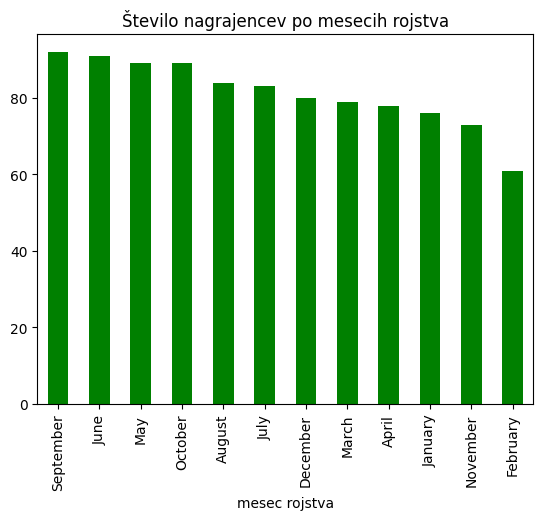

In [ ]:
datum_rojstva = nagrajenci[nagrajenci["datum rojstva"] != "/"]
nagrajenci[["dan rojstva", "mesec rojstva"]] = nagrajenci["datum rojstva"].str.extract(
    r"(\d+ )([a-zA-Z]+)"
)
po_mesecih_rojstva = nagrajenci["mesec rojstva"].value_counts()
graf_mesecev = po_mesecih_rojstva.plot.bar(
    title="Število nagrajencev po mesecih rojstva", color="green"
)

### ANALIZA PO DRŽAVAH

Odkod prihaja največ nagrajencev oziroma v kateri državi se je rodilo največ nagrajencev

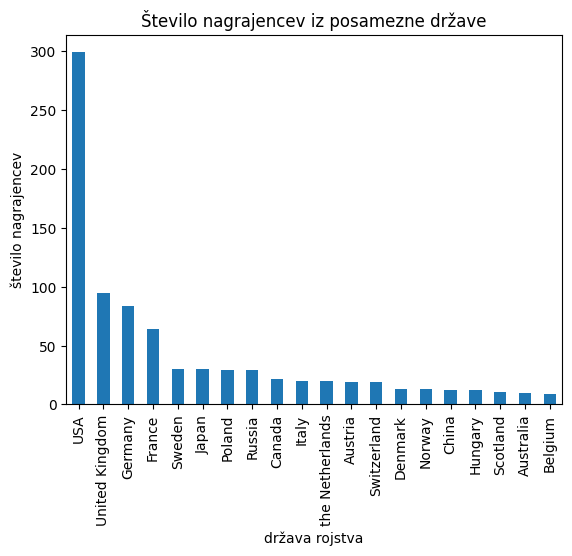

In [12]:
drzava_brez_pomisl = nagrajenci[nagrajenci["država rojstva"] != "/"]
drzave_po_nagrajencih = drzava_brez_pomisl["država rojstva"].value_counts()

# drzave_po_nagrajencih
drzave_graf = drzave_po_nagrajencih.head(20).plot.bar(
    ylabel="število nagrajencev", title="Število nagrajencev iz posamezne države"
)

Koliko in kam so se preselili Nobelovi nagrajenci

In [13]:
drzave_selitve = nagrajenci[
    (nagrajenci["država rojstva"] != "/") & (nagrajenci["država smrti"] != "/")
]
# len(drzave_selitve)
print(
    f"Število nagrajencev, ki se je rodilo v drugi državi kot je umrlo znaša: {len(drzave_selitve)}"
)

Število nagrajencev, ki se je rodilo v drugi državi kot je umrlo znaša: 680


In [14]:
najveckrat_drzava_selitve = drzave_selitve["država smrti"].value_counts()
# drzave_selitve['datum rojstva']
drzava_najveckrat = najveckrat_drzava_selitve.index[0]
iz_katre_drzave_preselili = nagrajenci[
    (nagrajenci["država smrti"] == drzava_najveckrat)
    & (nagrajenci["država rojstva"] != drzava_najveckrat)
]
najveckrat_rojstvo = iz_katre_drzave_preselili["država rojstva"].value_counts()

print(
    f"Nobelovi nagrajenci so se največkrat preselili v {drzava_najveckrat}.\n"
    f"Največ Nobelovih nagrajencev se je preselilo iz {najveckrat_rojstvo.index[0]} v {drzava_najveckrat}."
)

Nobelovi nagrajenci so se največkrat preselili v USA.
Največ Nobelovih nagrajencev se je preselilo iz Germany v USA.


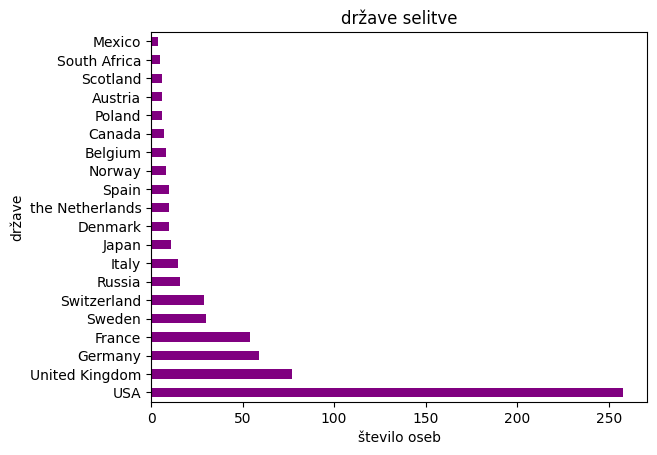

In [15]:
graf_drzav_selitev = najveckrat_drzava_selitve.head(20).plot.barh(
    title="države selitve", color="purple"
)
yos = plt.ylabel("države")
xos = plt.xlabel("število oseb")

Koliko nagrajencev prihaja iz točno določene države

In [95]:
drzava = "Slovenia"  # izbereš želeno državo rojstva
drzave_sez = []
for i in nagrajenci["država rojstva"]:
    if i not in drzave_sez:
        drzave_sez.append(i)

if drzava in drzave_sez:
    stevilo = nagrajenci[nagrajenci["država rojstva"] == drzava]

    if stevilo["država rojstva"].value_counts().iloc[0] == 1:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država rojstva'].value_counts().iloc[0]} oseba."
        )
    elif stevilo["država rojstva"].value_counts().iloc[0] == 2:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država rojstva'].value_counts().iloc[0]} osebi."
        )
    elif stevilo["država rojstva"].value_counts().iloc[0] > 2:
        print(
            f"Iz {drzava} je prejelo Nobelovo nagrado {stevilo['država rojstva'].value_counts().iloc[0]} oseb."
        )
else:
    print(f"{drzava} nima nobenega nagrajenca.")

Iz Slovenia je prejelo Nobelovo nagrado 1 oseba.


### ANALIZA PO LETIH ROJSTVA